In [1]:
import pandas as pd

# Load metadata
metadata = pd.read_csv("../data/metadata_clean.csv")
print(f"Metadata shape: {metadata.shape}")
metadata.head(10)

Metadata shape: (80, 9)


,subjectid,barcode,ad.disease.status,braak.stage,Sex,age.blood,age.brain,source tissue,sample_id
0,1,6042316048_R05C01,C,0.0,FEMALE,79.0,82,frontal cortex,GSM1443251
1,4,7786923107_R02C01,C,1.0,FEMALE,77.0,81,frontal cortex,GSM1443263
2,5,6042316121_R04C02,C,2.0,FEMALE,90.0,92,frontal cortex,GSM1443269
3,6,6042316099_R01C01,C,1.0,MALE,78.0,78,frontal cortex,GSM1443270
4,8,6042316099_R02C01,AD,4.0,FEMALE,94.0,96,frontal cortex,GSM1443283
5,9,6042316094_R06C02,AD,6.0,FEMALE,92.0,90,frontal cortex,GSM1443285
6,10,7796806016_R03C02,AD,6.0,MALE,81.0,82,frontal cortex,GSM1443289
7,11,6042316066_R06C01,AD,6.0,FEMALE,87.0,89,frontal cortex,GSM1443298
8,12,6042316094_R03C02,AD,6.0,MALE,90.0,91,frontal cortex,GSM1443299
9,13,6042316110_R04C01,AD,5.0,FEMALE,79.0,80,frontal cortex,GSM1443304


In [2]:
# Load beta matrix preview (first 10 CpGs, first 5 samples)
beta_preview = pd.read_csv(
    "../data/beta_matrix_full.csv",
    skiprows=4,
    index_col=0,
    nrows=10
)
print(f"Preview shape: {beta_preview.shape}")
beta_preview.iloc[:, :5]

Preview shape: (10, 531)


,6042316035_R01C01,6042316035_R02C02,6042316035_R03C01,6042316035_R03C02,6042316035_R04C01
NaN,GSM1443279,GSM1443663,GSM1443434,GSM1443547,GSM1443577
NaN,GSM1068948,GSM1068949,GSM1068950,GSM1068951,GSM1068952
cg00000029,0.559132026023056,0.620021609304793,0.516108718242472,0.537237945367319,0.552570973189937
cg00000108,0.873276613178559,0.915872655387061,0.917385718004504,0.910278245689418,0.890679613629184
cg00000109,0.740187010693145,0.756004343671838,0.766045638989485,0.767177319747908,0.725826105888431
cg00000165,0.246976966955097,0.232916985846698,0.238165192252813,0.265406235267096,0.241584353630269
cg00000236,0.815449127110117,0.808495538207229,0.808723033340597,0.797502669843095,0.785903918589561
cg00000289,0.4829337653726,0.512257871995516,0.468610352716195,0.579091657668052,0.485917732252484
cg00000292,0.639504321086337,0.69370672289705,0.68229347280642,0.692812623734974,0.690696861686032
cg00000321,0.526874590805178,0.651751882755481,0.653019718263611,0.553525911708253,0.581792061146274


In [4]:
# Get full shape of beta matrix without loading entire file into memory
import subprocess

# Count rows (subtract 6: 3 comment lines, 1 blank, 2 header rows)
result = subprocess.run(['wc', '-l', '../data/beta_matrix_full.csv'], capture_output=True, text=True)
total_lines = int(result.stdout.strip().split()[0])
n_rows = total_lines - 6  # subtract non-data lines

# Get column count from header line (line 5, index 4)
with open('../data/beta_matrix_full.csv', 'r') as f:
    for i, line in enumerate(f):
        if i == 4:  # the header line with barcodes
            n_cols = len(line.strip().split(','))
            break

print(f"Full beta matrix shape: {n_rows} CpG sites x {n_cols} samples")
print(f"That's {n_rows * n_cols:,} total values")
print(f"Memory estimate if fully loaded: ~{(n_rows * n_cols * 8) / 1e9:.1f} GB")

Full beta matrix shape: 485578 CpG sites x 532 samples
That's 258,327,496 total values
Memory estimate if fully loaded: ~2.1 GB


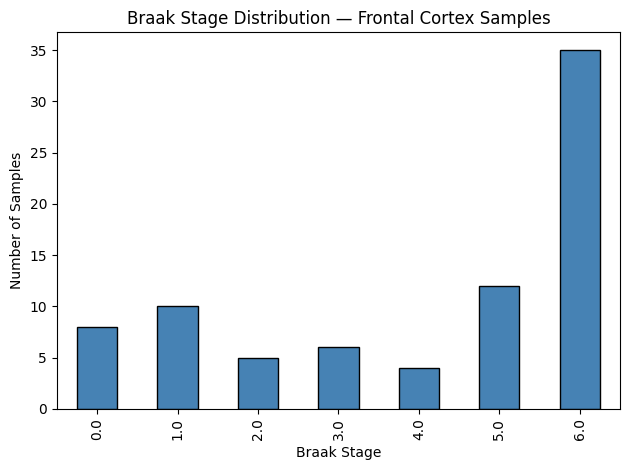

In [3]:
import matplotlib.pyplot as plt

metadata["braak.stage"].value_counts().sort_index().plot(
    kind="bar", color="steelblue", edgecolor="black"
)
plt.xlabel("Braak Stage")
plt.ylabel("Number of Samples")
plt.title("Braak Stage Distribution — Frontal Cortex Samples")
plt.tight_layout()
plt.show()

In [5]:
# Summary stats on Braak stage
print("Braak stage summary:")
print(metadata["braak.stage"].describe())
print(f"\nMedian Braak stage: {metadata['braak.stage'].median()}")

# Age and sex breakdown
print(f"\nSex distribution:\n{metadata['Sex'].value_counts()}")
print(f"\nAge at death (brain) summary:\n{metadata['age.brain'].describe()}")

Braak stage summary:
count    80.000000
mean      4.050000
std       2.238331
min       0.000000
25%       2.000000
50%       5.000000
75%       6.000000
max       6.000000
Name: braak.stage, dtype: float64

Median Braak stage: 5.0

Sex distribution:
Sex
FEMALE    49
MALE      31
Name: count, dtype: int64

Age at death (brain) summary:
count     80.000000
mean      84.025000
std        9.485465
min       55.000000
25%       80.000000
50%       85.000000
75%       91.000000
max      103.000000
Name: age.brain, dtype: float64
